## Note: Use embeddings for the notes, and think later about time and step time

# Experiment Number

In [237]:
from numpy.ma.extras import unique

ExpNumber = 1

# Import Libraries

In [238]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pretty_midi
from os import listdir
from os.path import isfile, join

In [239]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
device

device(type='mps')

# Functions

In [240]:
def read_midi(midi_path_folder: str):
    """Reads all the MIDI files in a folder and store them in a list [pitch, duration, step]"""
    mypath = midi_path_folder
    onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f)) and f.lower().endswith(('.mid', '.midi'))]
    print(f'There are {len(onlyfiles)} MIDI files inside this folder: \n{onlyfiles}')

    sorted_notes_append = []  # Format [[m1],[m2],[m3]] where m is a full piece in the format [p1,d1,s1],..[pn,dn,sn]
    sorted_notes_extend = []  # Format [m1,m2,m3], Every piece follows one after another as if one big piece.

    # Iterate each piece(file)
    for file in onlyfiles:
        notes = []
        midi_file = pretty_midi.PrettyMIDI(join(mypath, file))
        _, tempo = midi_file.get_tempo_changes()
        seconds_per_beat = np.round(tempo[0])# 84 BPM Guarania
        print(f'Tempo: {tempo} seconds per beat: {seconds_per_beat}')
        for instrument in midi_file.instruments:
            sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
            prev_start = sorted_notes[0].start
            for note in sorted_notes:
                start_time = note.start
                duration = round((note.end - note.start)/seconds_per_beat, 4) # In beats
                pitch = note.pitch
                step = round((start_time - prev_start)/seconds_per_beat, 4) # In beats
                notes.append([pitch, duration, step])
                prev_start = start_time
        sorted_notes_append.append(notes)
        sorted_notes_extend.extend(notes)
    return sorted_notes_append, sorted_notes_extend


In [241]:
def create_sequences(all_pieces, sequence_length):
    """Create Sequences for training"""
    X = []
    y = []

    for piece in all_pieces:

        for i in range(len(piece) - sequence_length):
            sequence = piece[i:  i+sequence_length ]
            target = piece[i+1 : i+sequence_length+1]

            X.append(sequence)
            y.append(target)

    return np.array(X), np.array(y)

# Data Preparation

In [256]:
#midi_path = 'datasetGuarania/'
midi_path = 'datasetBarrios/'
print(midi_path)

datasetBarrios/


In [257]:
seconds_per_beat = 60/84 # 84 BPM Guarania

In [261]:
for file in listdir(midi_path):
    if file.lower().endswith(('.mid', '.midi')):
        midi = pretty_midi.PrettyMIDI(join(midi_path, file))
        _,tempo = midi.get_tempo_changes()
        print(_)

[0.]
[  0.          13.4210325   13.786886    13.972071    15.472071
  16.5773325   17.05605525  17.2173455   17.70647525  17.87131025
  18.37130975  18.539849    19.0512125   19.22362625  19.74688175
  19.92335225  20.459066    21.181957    25.4451085   25.764257
  25.92554725  26.25163375  26.41646875  26.74980175  26.918341
  27.25925     29.328215    33.2755775   33.594726    33.75601625
  34.08210275  34.24693775  34.58027075  34.74881     35.089719
  36.8138565   43.287531    43.443781    43.596842    43.748357
  43.898357    44.04687175  44.1939305   44.1939305   44.67780125
  44.96351525  64.06874975  64.23004     64.39308325  64.55974975
  64.73020425  64.902618    65.0790885   65.25981125  65.442738
  65.630238    65.8225455   66.0173505   66.0173505   93.01731
  93.17356     93.326621    93.478136    93.628136    93.77665075
  93.9237095   93.9237095   94.6737095   94.9594235   98.906786
  99.06982925  99.23649575  99.40695025  99.58342075  99.7663475
  99.9538475  100.14615

In [245]:
data_append, data_extend = read_midi(midi_path)

There are 7 MIDI files inside this folder: 
['6. Recuerdos de Ypacarai - Demetrio Ortiz.mid', '2. Lejania - Herminio Gimenez.mid', '7. Saudade - Mario Palmeiro.mid', '5. Panambi Vera - Jose Asuncion Flores.mid', '1. India - Jose Asuncion Flores.mid', '3. Mis Noches sin ti -  Demetrio Ortiz.mid', '4. Nde Rendape Aju - Jose Asuncion Flores.mid']
Tempo: [84.000084] seconds per beat: 84.0
Tempo: [84.000084] seconds per beat: 84.0
Tempo: [84.000084] seconds per beat: 84.0
Tempo: [84.000084] seconds per beat: 84.0
Tempo: [84.000084] seconds per beat: 84.0
Tempo: [84.000084] seconds per beat: 84.0
Tempo: [84.000084] seconds per beat: 84.0


In [246]:
unique_pitch = sorted(set(row[0] for row in data_extend))
unique_duration = sorted(set(row[1] for row in data_extend))
unique_step = sorted(set(row[2] for row in data_extend))

print("\nPitch:\n", unique_pitch, len(unique_pitch))
print("\n\nDuration:\n", unique_duration, len(unique_duration))
print("\n\nStep:\n", unique_step, len(unique_step))


Pitch:
 [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 89, 91, 93] 57


Duration:
 [np.float64(0.0001), np.float64(0.0002), np.float64(0.0004), np.float64(0.0005), np.float64(0.0006), np.float64(0.0007), np.float64(0.0008), np.float64(0.0009), np.float64(0.001), np.float64(0.0011), np.float64(0.0012), np.float64(0.0014), np.float64(0.0015), np.float64(0.0016), np.float64(0.0017), np.float64(0.0018), np.float64(0.0019), np.float64(0.0021), np.float64(0.0024), np.float64(0.0027), np.float64(0.003), np.float64(0.0031), np.float64(0.0032), np.float64(0.0033), np.float64(0.0036), np.float64(0.0038), np.float64(0.004), np.float64(0.0043), np.float64(0.0053), np.float64(0.0064), np.float64(0.0066), np.float64(0.0068), np.float64(0.0069), np.float64(0.0074), np.float64(0.0081), np.float64(0.0085), np.float64(0.0121), np.float

In [247]:
# Map the values
pitch_to_idx = {value: i for i, value in enumerate(unique_pitch)}
duration_to_idx = {value: i for i, value in enumerate(unique_duration)}
step_to_idx = {value: i for i, value in enumerate(unique_step)}

# For generation
idx_to_pitch = {i: value for i, value in enumerate(unique_pitch)}
idx_to_duration = {i: value for i, value in enumerate(unique_duration)}
idx_to_step = {i: value for i, value in enumerate(unique_step)}

In [248]:
def encode_piece(piece, pitch_to_idx, duration_to_idx, step_to_idx):
    encoded = []

    for pitch, duration, step in piece:
        encoded.append([
            pitch_to_idx[pitch],
            duration_to_idx[duration],
            step_to_idx[step]
        ])

    return encoded

In [249]:
encoded_pieces = [
                  encode_piece(piece, pitch_to_idx, duration_to_idx, step_to_idx) for piece in data_append
                 ]

In [250]:
seq_length = 30
X, y = create_sequences(encoded_pieces, sequence_length=seq_length)
X = torch.tensor(X, dtype=torch.long).to(device)
y = torch.tensor(y, dtype=torch.long).to(device)

In [251]:
X,y

(tensor([[[ 3,  9,  0],
          [ 8,  9, 11],
          [10,  9, 11],
          ...,
          [42,  9, 11],
          [45,  9, 11],
          [42,  9, 11]],
 
         [[ 8,  9, 11],
          [10,  9, 11],
          [13,  9, 11],
          ...,
          [45,  9, 11],
          [42,  9, 11],
          [38,  9, 11]],
 
         [[10,  9, 11],
          [13,  9, 11],
          [15,  9, 11],
          ...,
          [42,  9, 11],
          [38,  9, 11],
          [36,  9, 11]],
 
         ...,
 
         [[43,  6,  3],
          [29,  7,  6],
          [43,  6,  5],
          ...,
          [43,  6, 11],
          [43,  6, 11],
          [43,  6, 11]],
 
         [[29,  7,  6],
          [43,  6,  5],
          [30,  7,  4],
          ...,
          [43,  6, 11],
          [43,  6, 11],
          [43,  6, 11]],
 
         [[43,  6,  5],
          [30,  7,  4],
          [43,  6,  6],
          ...,
          [43,  6, 11],
          [43,  6, 11],
          [43,  6, 11]]], device='mps:0

# Model Definition

In [252]:
# layer parameters
pitch_vocab_size = len(unique_pitch)
duration_vocab_size = len(unique_duration)
step_vocab_size = len(unique_step)
hidden_size = 128 # Number of units in the hidden state
num_layers = 2

In [253]:
class DeepStrum(nn.Module):
    def __init__(self, pitch_vocab_size, duration_vocab_size, step_vocab_size, hidden_size, num_layers):
        super().__init__()

        self.pitch_embedding = nn.Embedding(pitch_vocab_size, 16)
        self.duration_embedding = nn.Embedding(duration_vocab_size, 8)
        self.step_embedding = nn.Embedding(step_vocab_size, 8)

        self.lstm = nn.LSTM(16+8+8, hidden_size, num_layers, batch_first=True) # (batch, sequence, features)

        # Classification Problem
        self.pitch_out = nn.Linear(hidden_size, pitch_vocab_size)
        self.duration_out = nn.Linear(hidden_size, duration_vocab_size)
        self.step_out = nn.Linear(hidden_size, step_vocab_size)

    def forward(self,x,h):

        pitch = x[:, :, 0]
        duration = x[:, :, 1]
        step = x[:, :, 2]

        pitch = self.pitch_embedding(pitch)
        duration = self.duration_embedding(duration)
        step = self.step_embedding(step)

        x = torch.cat([pitch, duration, step], dim=-1)

        y, h = self.lstm(x, h)

        pitch_out = self.pitch_out(y)
        duration_out = self.duration_out(y)
        step_out = self.step_out(y)

        return pitch_out, duration_out, step_out, h

In [254]:
deepStrum = DeepStrum(pitch_vocab_size=pitch_vocab_size,duration_vocab_size=duration_vocab_size,step_vocab_size=step_vocab_size,hidden_size=hidden_size,num_layers=num_layers).to(device)

# Loss Function and Optimizer
lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(deepStrum.parameters(), lr=0.001)


# Training

In [255]:
epochs = 15

losses = np.zeros(epochs)

for epoch in range(epochs):

    batchloss = 0

    for i in range(len(X)):

        x = X[i].unsqueeze(0)       # [1, 30, 3]
        target = y[i].unsqueeze(0)  # [1, 30, 3]

        # Forward pass
        pitch_out, duration_out, step_out, h = deepStrum(x, None)

        # Targets
        pitch_target = target[:, :, 0]       # [1, 30]
        duration_target = target[:, :, 1]     # [1, 30]
        step_target = target[:, :, 2]         # [1, 30]

        # Loss
        pitch_loss = lossfun(
            pitch_out.transpose(1, 2),
            pitch_target
        )

        duration_loss = lossfun(
            duration_out.transpose(1, 2),
            duration_target
        )

        step_loss = lossfun(
            step_out.transpose(1, 2),
            step_target
        )

        loss = pitch_loss + duration_loss + step_loss

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batchloss += loss.item()

    losses[epoch] = batchloss / len(X)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[epoch]:.4f}")

Epoch 1/15, Loss: 4.5494
Epoch 2/15, Loss: 2.9834
Epoch 3/15, Loss: 2.0897


KeyboardInterrupt: 

# Results

In [184]:
numPred = 200

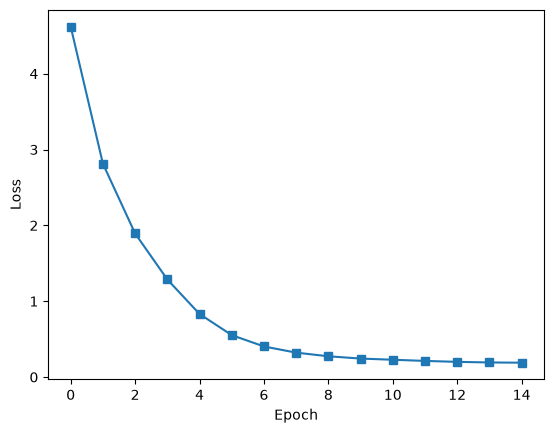

In [185]:
# check out the losses
plt.plot(losses,'s-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [186]:
def generate_midi(
    model,
    seed_sequence,
    num_notes,
    pitch_idx_to_value,
    duration_idx_to_value,
    step_idx_to_value,
    output_file="generated_piece.mid",
    bpm=84,
    top_k=2,
    device="cpu"
):
    model.eval()

    # Convert seed to tensor
    sequence = torch.tensor(
        seed_sequence,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)  # [1, sequence_length, 3]

    generated_notes = []

    with torch.no_grad():

        for _ in range(num_notes):

            # Model prediction
            pitch_out, duration_out, step_out, _ = model(
                sequence,
                None
            )

            # Take prediction for the LAST timestep
            pitch_logits = pitch_out[:, -1, :]
            duration_logits = duration_out[:, -1, :]
            step_logits = step_out[:, -1, :]

            # Convert logits to probabilities
            pitch_probs = torch.softmax(pitch_logits, dim=-1)
            duration_probs = torch.softmax(duration_logits, dim=-1)
            step_probs = torch.softmax(step_logits, dim=-1)

            # Get top-k candidates
            pitch_top_probs, pitch_top_idx = torch.topk(
                pitch_probs, top_k, dim=-1
            )

            duration_top_probs, duration_top_idx = torch.topk(
                duration_probs, top_k, dim=-1
            )

            step_top_probs, step_top_idx = torch.topk(
                step_probs, top_k, dim=-1
            )

            # Normalize probabilities of top-k
            pitch_top_probs = pitch_top_probs / pitch_top_probs.sum(dim=-1, keepdim=True)
            duration_top_probs = duration_top_probs / duration_top_probs.sum(dim=-1, keepdim=True)
            step_top_probs = step_top_probs / step_top_probs.sum(dim=-1, keepdim=True)

            # Randomly sample from top-k
            pitch_choice = torch.multinomial(pitch_top_probs, 1)
            duration_choice = torch.multinomial(duration_top_probs, 1)
            step_choice = torch.multinomial(step_top_probs, 1)

            # Get selected indices
            pitch_idx = pitch_top_idx.gather(1, pitch_choice).item()
            duration_idx = duration_top_idx.gather(1, duration_choice).item()
            step_idx = step_top_idx.gather(1, step_choice).item()

            # Convert indices back to actual MIDI values
            pitch = pitch_idx_to_value[pitch_idx]
            duration = duration_idx_to_value[duration_idx]
            step = step_idx_to_value[step_idx]

            generated_notes.append([
                pitch,
                duration,
                step
            ])

            # New event becomes the next input
            new_event = torch.tensor(
                [[[pitch_idx, duration_idx, step_idx]]],
                dtype=torch.long,
                device=device
            )

            # Remove oldest event and append new event
            sequence = torch.cat(
                [sequence[:, 1:, :], new_event],
                dim=1
            )

    # --------------------------------------------------
    # Create MIDI
    # --------------------------------------------------

    midi = pretty_midi.PrettyMIDI(initial_tempo=bpm)

    instrument = pretty_midi.Instrument(
        program=pretty_midi.instrument_name_to_program("Acoustic Grand Piano")
    )

    current_time = 0.0
    seconds_per_beat = 60.0 / bpm

    for pitch, duration, step in generated_notes:

        start = current_time

        end = start + duration * seconds_per_beat

        note = pretty_midi.Note(
            velocity=100,
            pitch=int(pitch),
            start=start,
            end=end
        )

        instrument.notes.append(note)

        # Step controls distance to next note
        current_time += step * seconds_per_beat

    midi.instruments.append(instrument)

    midi.write(output_file)

    print(f"Generated MIDI saved to: {output_file}")

    return generated_notes

In [187]:
seed = X[7].cpu().numpy()

In [190]:
generated = generate_midi(
    model=deepStrum,
    seed_sequence=seed,
    num_notes=400,
    pitch_idx_to_value=idx_to_pitch,
    duration_idx_to_value=idx_to_duration,
    step_idx_to_value=idx_to_step,
    output_file="Output/generated_guarania.mid",
    bpm=84,
    top_k=3,
    device=device
)

Generated MIDI saved to: generated_guarania.mid
